<a href="https://colab.research.google.com/github/Sam-Gyu/ML-From-Scratch-PCA-NaiveBayes-/blob/main/PCA%26NaiveBayes__Comparative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
---

# ***Numerical Dataset***

---
---



# Important Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

# Data Loading

In [ ]:
breast_data = load_breast_cancer()

X = pd.DataFrame(breast_data.data, columns=breast_data.feature_names)
y = pd.Series(breast_data.target, name="target")

In [ ]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
X.shape

(569, 30)

In [ ]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


# EDA

target
1    357
0    212
Name: count, dtype: int64


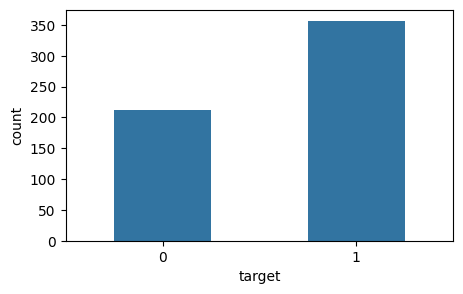

In [ ]:
print(y.value_counts())
plt.figure(figsize=(5,3))
sns.countplot(x=y, width=0.5)
plt.show()

In [ ]:
df = X.copy()
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.shape

(569, 31)

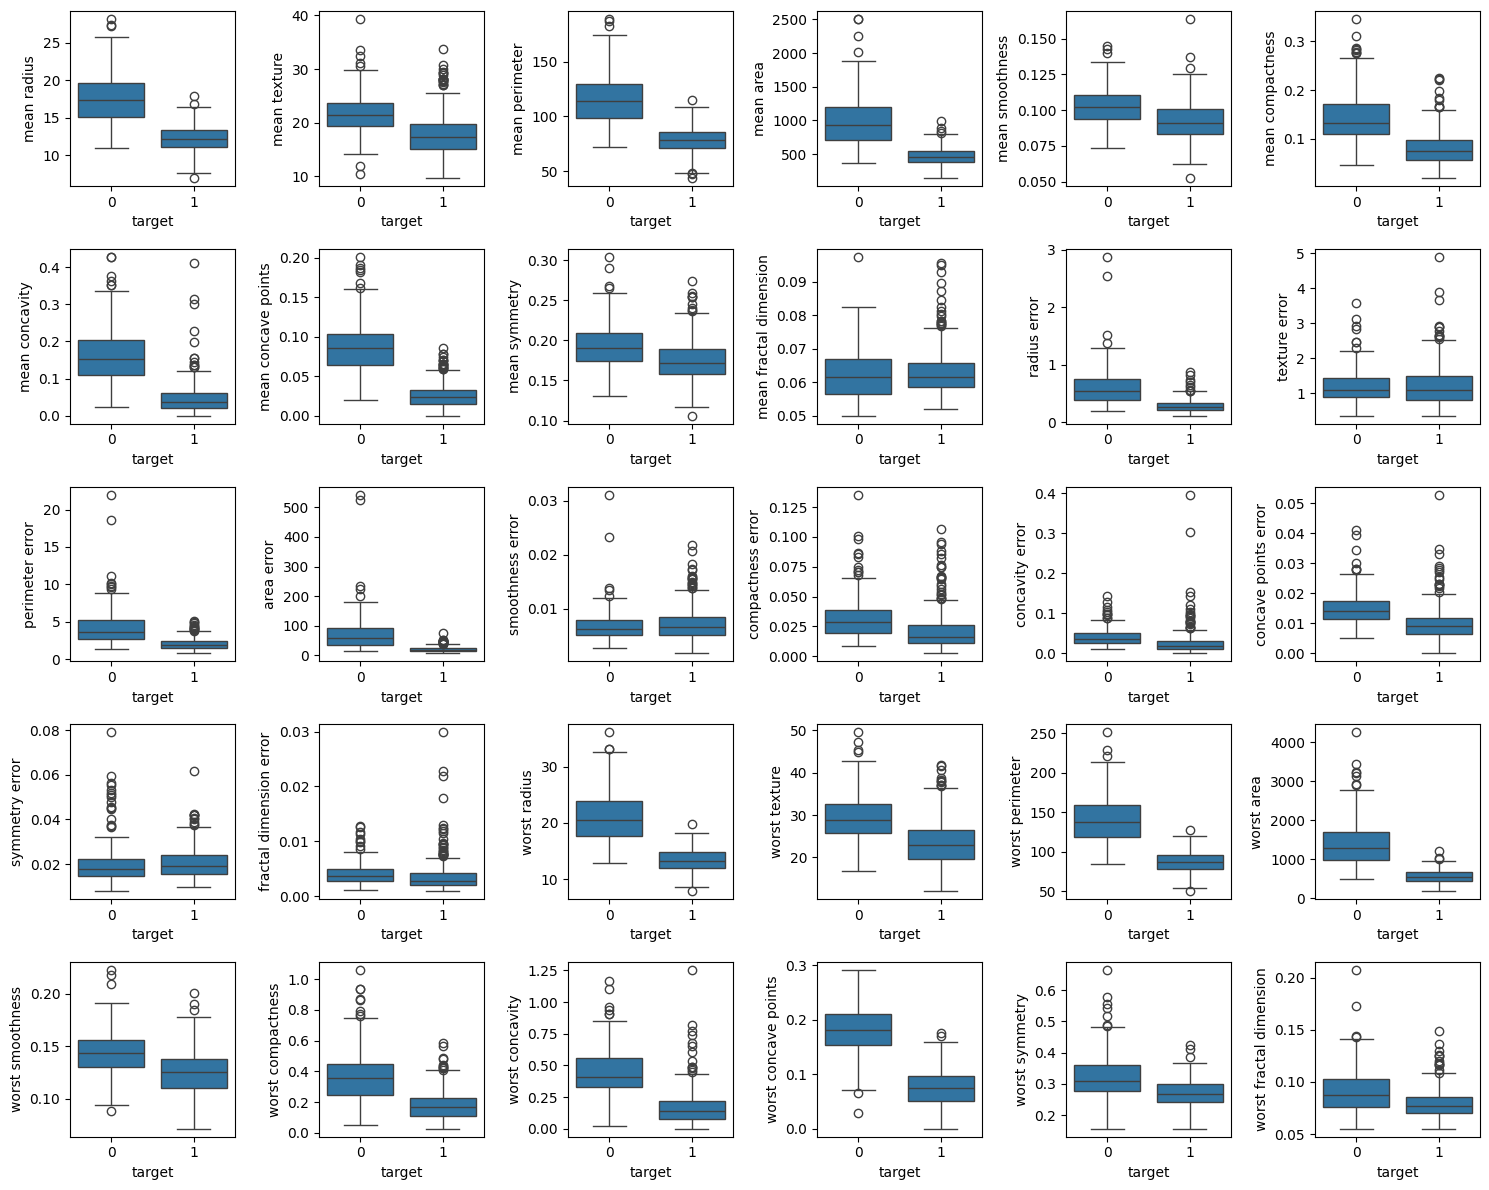

In [ ]:
plt.figure(figsize=(15, 12))
for i,col in enumerate(X.columns):
  plt.subplot(5,6,i+1)
  sns.boxplot(x='target', y=col, data=df)
  plt.tight_layout()
plt.show()


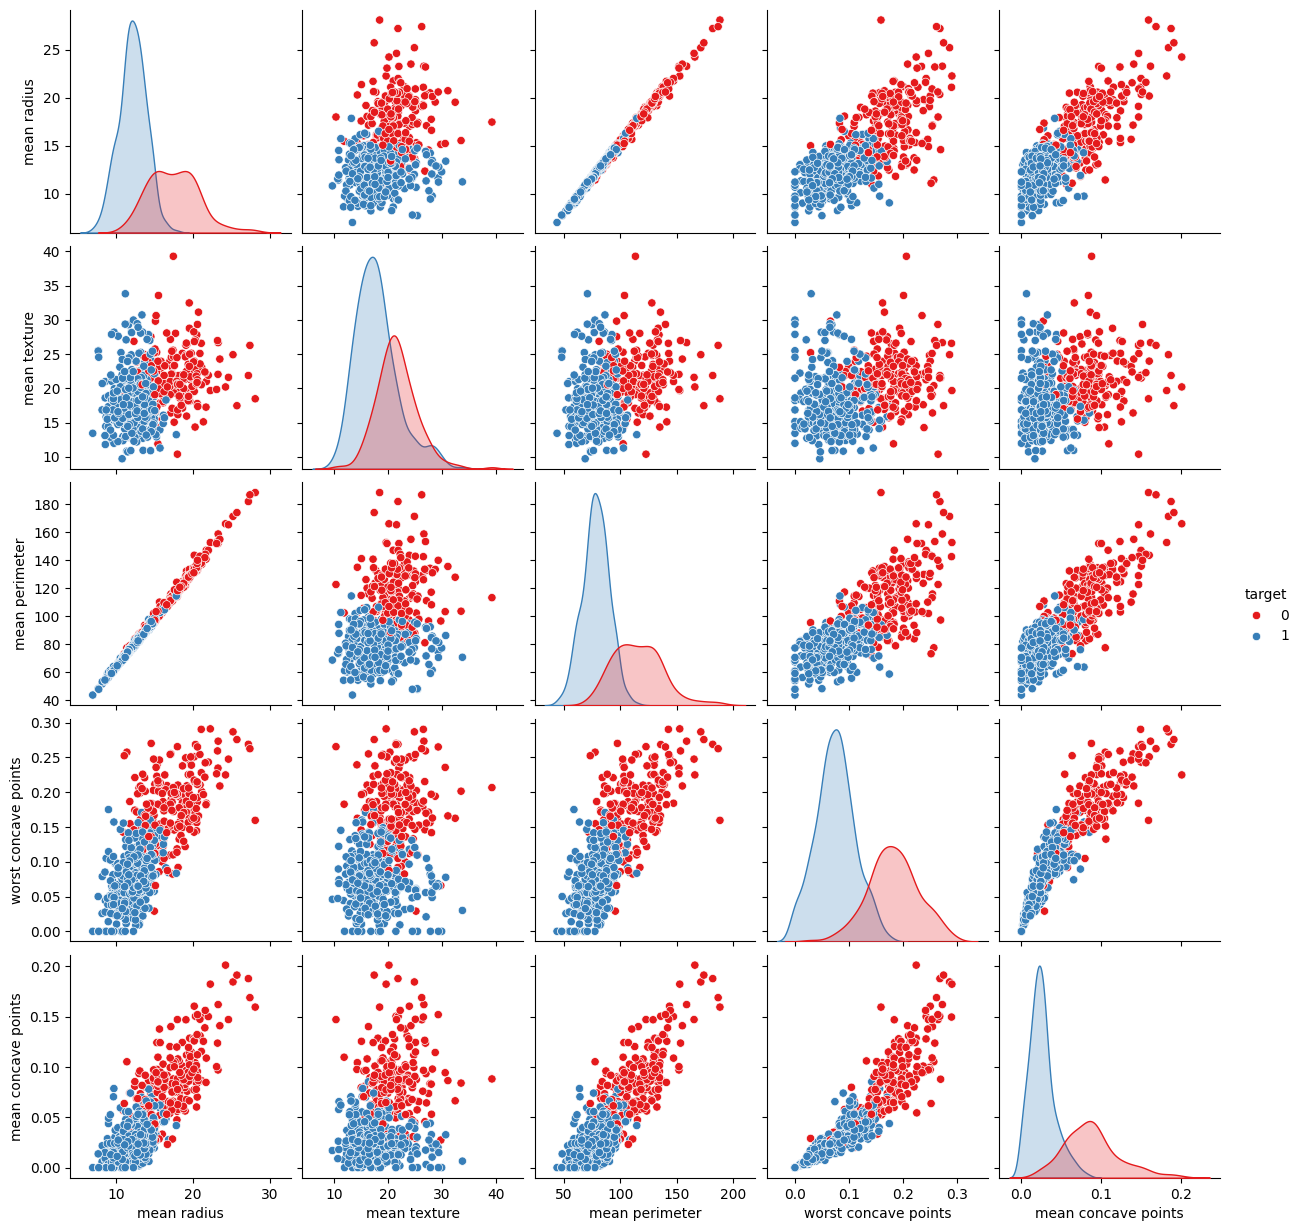

In [ ]:
important_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "worst concave points",
    "mean concave points"
]
sns.pairplot(df, vars=important_features, hue='target', palette='Set1')
plt.show()

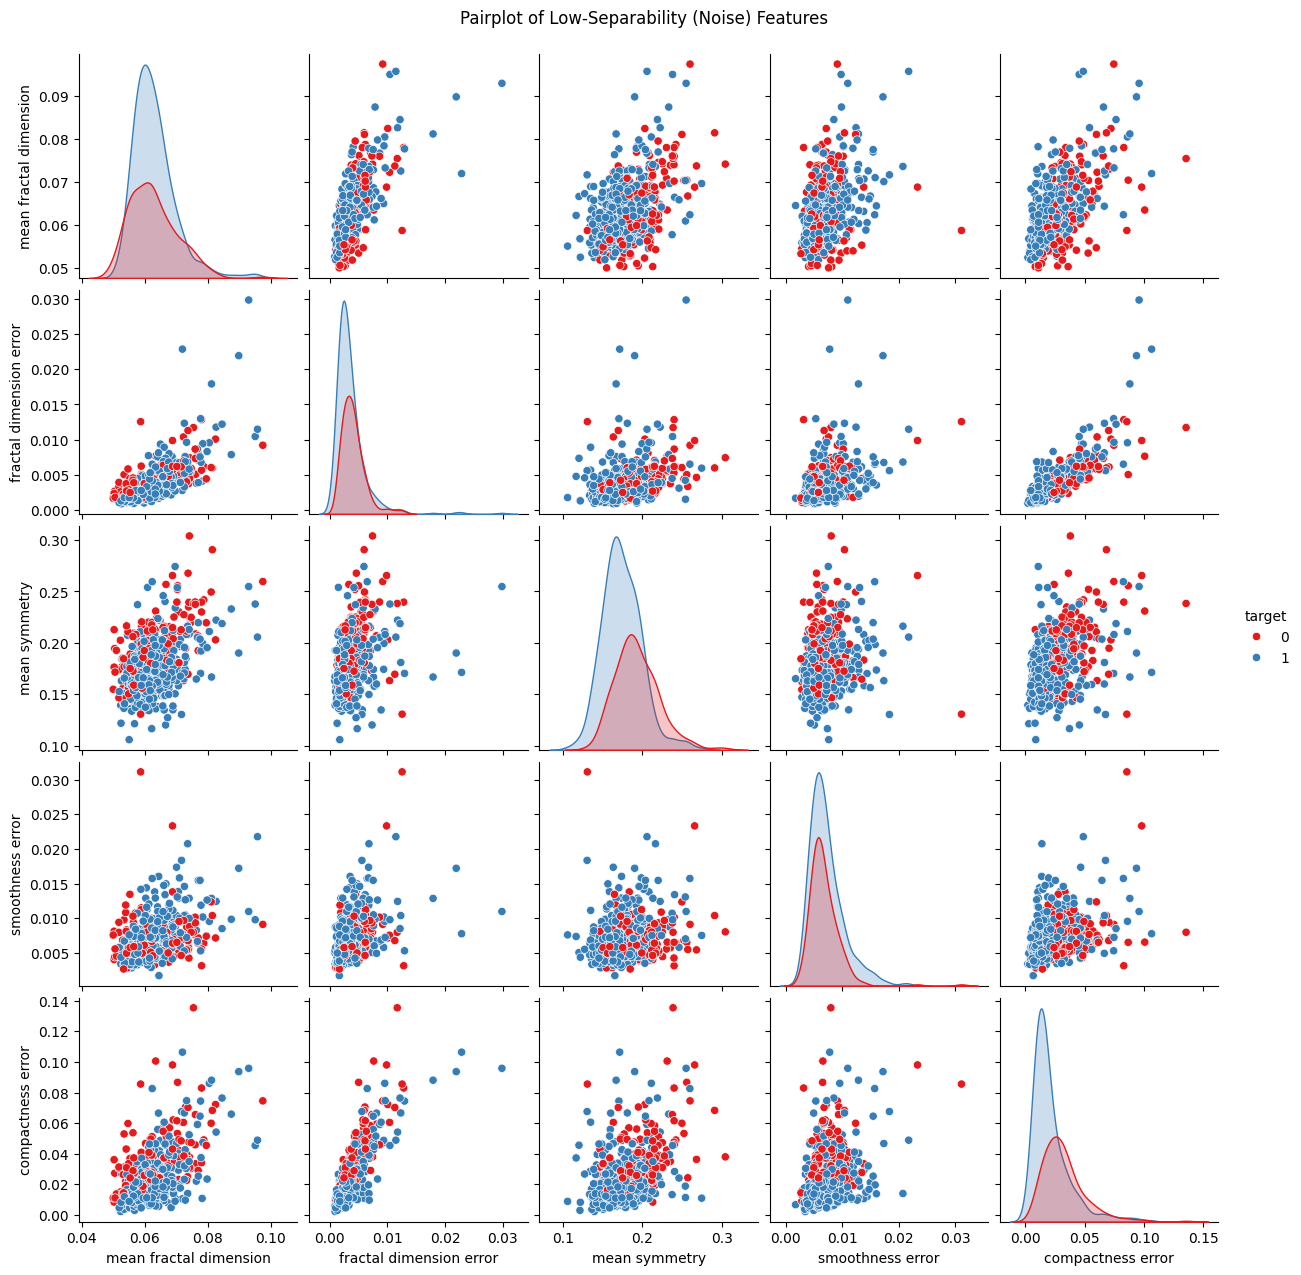

In [ ]:
unimportant_features = [
    "mean fractal dimension",
    "fractal dimension error",
    "mean symmetry",
    "smoothness error",
    "compactness error"
]

sns.pairplot(df, vars=unimportant_features, hue='target', palette='Set1')
plt.suptitle("Pairplot of Low-Separability (Noise) Features", y=1.02)
plt.show()

# Split into Training/Testing & Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scale = StandardScaler()
X_train_processed = scale.fit_transform(X_train)
X_test_processed = scale.transform(X_test)

# PCA From Scratch

In [ ]:
def pca(X_processed, k):
  # X is  data matrix of shape (n_samples, n_features)
  # 1- COVARIANCE MATRIX
  #  mean vector
  mean_vec = np.mean(X_processed, axis=0)  # shape: (n_features,)

  # subtract the mean
  shifted_mean = X_processed - mean_vec      # shape: (n_samples, n_features)

  # transpose of centered data
  transposeofsub = np.transpose(shifted_mean)  # shape: (n_features, n_samples)

  # number of samples
  n_samples = X_processed.shape[0]

  # covariance matrix
  cov_mat = np.dot(transposeofsub, shifted_mean) / n_samples  # shape: (n_features, n_features)

  # 2- EIGEN VALUES AND EIGEN VECTORS
  # compute eigenvalues and eigenvectors
  eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)

  # The Goal: In PCA, the largest eigenvalue corresponds to the direction of maximum variance.
  sorted_indices = np.argsort(eigen_values)[::-1]  # indices of sorted eigenvalues
  eigen_values = eigen_values[sorted_indices]    # values of eignvalues
  eigen_vectors = eigen_vectors[:, sorted_indices]     # reorder eigenvectors by eigenvalues (largest first → most important PC)

  # Select the top k eigenvectors
  best_vectors = eigen_vectors[:, :k]

  # Project the original centered data onto the new components
  # Centered data is 'shifted_mean'
  X_reduced = np.dot(shifted_mean, best_vectors)

  return X_reduced, eigen_values, best_vectors, mean_vec

# Gaussian Naive Bayes From Scratch

In [ ]:
def fit_gaussian_nb(X, y):
    classes = np.unique(y)
    mean = {}
    var = {}
    priors = {}

    for c in classes:
        X_c = X[y == c]
        mean[c] = X_c.mean(axis=0)
        var[c] = X_c.var(axis=0)
        priors[c] = X_c.shape[0] / X.shape[0]

    return classes, mean, var, priors

def gaussian_prob(x, mean, var):
    eps = 1e-6 # Small value to prevent division by zero in variance
    coeff = (1 / np.sqrt(2 * np.pi * var))
    exponent = np.exp(-(x - mean)**2 / (2 * var + eps))
    return coeff * exponent

def predict_gaussian_nb(X, classes, mean, var, priors):
    y_pred = []

    for x in X:
        posteriors = []
        for c in classes:
            prior = np.log(priors[c])  # log to prevent underflow
            likelihood = np.sum(np.log(gaussian_prob(x, mean[c], var[c])))
            posterior = prior + likelihood
            posteriors.append(posterior)
        y_pred.append(classes[np.argmax(posteriors)])

    return np.array(y_pred)

# confusion matrix function

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Experiment 0: Baseline (All Features + Naive Bayes)

In [ ]:
classes, mean, var, priors = fit_gaussian_nb(X_train_processed, y_train)
y_pred = predict_gaussian_nb(X_test_processed, classes, mean, var, priors)

print("=== Experiment 0: Baseline (All Features) ===")
acc_baseline = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc_baseline:.4f} \n')
print('Classification Report:\n', classification_report(y_test, y_pred))


=== Experiment 0: Baseline (All Features) ===
Accuracy: 0.9649 

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



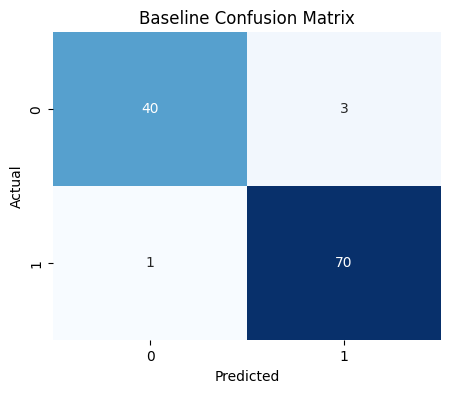

In [ ]:
plot_confusion_matrix(y_test, y_pred, 'Baseline Confusion Matrix')

# Experiment A: Feature Selection + Naive Bayes

In [ ]:
# Create a SelectKBest object that will select the top 2 features using the ANOVA F-test (f_classif)
# defines the selection rule. No features are selected yet
selector = SelectKBest(score_func=f_classif, k=2)

# Fit the selector to compute feature scores and select the best 2 features from the training data
X_tarin_fs = selector.fit_transform(X_train_processed, y_train)

# Apply the same feature selection (same 2 features) to the test data
X_test_fs = selector.transform(X_test_processed)

# Use custom Gaussian Naive Bayes
classes_fs, mean_fs, var_fs, priors_fs = fit_gaussian_nb(X_tarin_fs, y_train)
y_pred = predict_gaussian_nb(X_test_fs, classes_fs, mean_fs, var_fs, priors_fs)

print("\n=== Experiment A: Feature Selection (Top 5 Features) ===")
acc_fs = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc_fs:.4f} \n")
print("Classification Report:\n", classification_report(y_test, y_pred))


=== Experiment A: Feature Selection (Top 5 Features) ===
Accuracy: 0.9211 

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90        43
           1       0.96      0.92      0.94        71

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [ ]:
mask = selector.get_support()
selected_features = X.columns[mask]
print(f"Selected Features: {selected_features}")

Selected Features: Index(['mean concave points', 'worst concave points'], dtype='object')


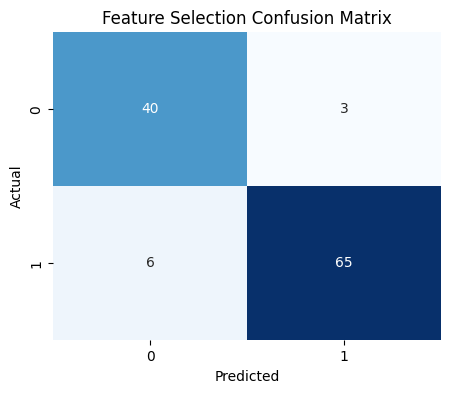

In [ ]:
plot_confusion_matrix(y_test, y_pred, 'Feature Selection Confusion Matrix')

# Experiment B: PCA (Feature Reduction) + Naive Bayes

In [ ]:
for k in [2, 3, 5, 8]:

    X_train_pca, eigen_vals, best_vectors, mean_vec = pca(X_train_processed, k)

    X_test_shifted = X_test_processed - mean_vec
    X_test_pca = np.dot(X_test_shifted, best_vectors)

    # Use custom Gaussian Naive Bayes
    classes_pca, mean_pca, var_pca, priors_pca = fit_gaussian_nb(X_train_pca, y_train)
    y_pred = predict_gaussian_nb(X_test_pca, classes_pca, mean_pca, var_pca, priors_pca)

    print(f"\n=== Experiment B: PCA (k={k}) ===")
    acc_pca = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc_pca:.8f}\n")
    print("Classification Report:\n", classification_report(y_test, y_pred))


=== Experiment B: PCA (k=2) ===
Accuracy: 0.94736842

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114


=== Experiment B: PCA (k=3) ===
Accuracy: 0.94736842

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114


=== Experiment B: PCA (k=5) ===
Accuracy: 0.94736842

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        43


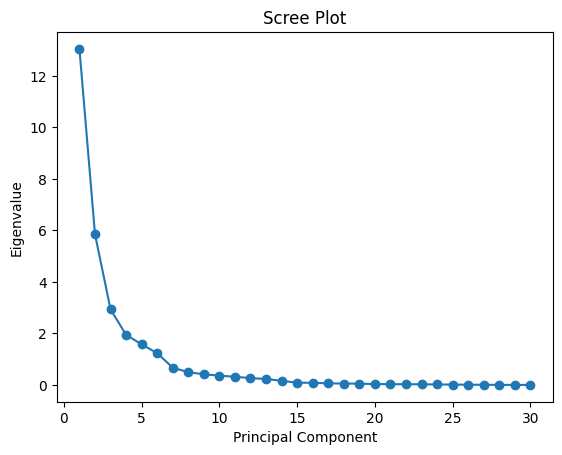

In [ ]:
# Scree Plot
plt.figure()
plt.plot(range(1, len(eigen_vals)+1), eigen_vals, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

In [ ]:
k = 2
X_train_pca, eigen_vals, best_vectors, mean_vec = pca(X_train_processed, k)

X_test_shifted = X_test_processed - mean_vec
X_test_pca = np.dot(X_test_shifted, best_vectors)

classes_pca, mean_pca, var_pca, priors_pca = fit_gaussian_nb(X_train_pca, y_train)
y_pred = predict_gaussian_nb(X_test_pca, classes_pca, mean_pca, var_pca, priors_pca)

print(f"\n=== Experiment B: PCA (k={k}) ===")
acc_pca = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc_pca:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


=== Experiment B: PCA (k=2) ===
Accuracy: 0.9474

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



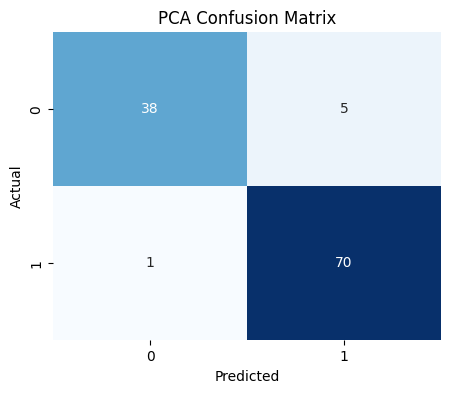

In [ ]:
plot_confusion_matrix(y_test, y_pred, 'PCA Confusion Matrix')

# Accuracy Comparison

In [ ]:
accuracy_results = {}

accuracy_results["Baseline"] = acc_baseline
accuracy_results["Feature Selection"] = acc_fs
accuracy_results["PCA (k=2)"] = acc_pca

In [ ]:
comparison_table = pd.DataFrame({
    "Experimen": accuracy_results.keys(),
    "Accuracy": accuracy_results.values()
})

print("\n=== Accuracy Comparison Table ===")
comparison_table


=== Accuracy Comparison Table ===


,Experimen,Accuracy
0,Baseline,0.964912
1,Feature Selection,0.921053
2,PCA (k=2),0.947368


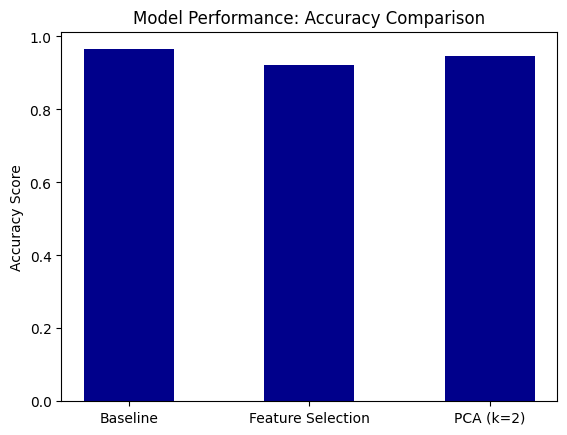

In [ ]:
plt.figure()
plt.bar(accuracy_results.keys(), accuracy_results.values(), width = 0.5, color='darkblue')
plt.ylabel("Accuracy Score")
plt.title("Model Performance: Accuracy Comparison")
plt.show()

---
---

# ***Categorical Dataset***

---
---



#  Dataset Loading & Overview

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"

columns = ['target', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
           'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
           'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
           'stalk-surface-below-ring', 'stalk-color-above-ring',
           'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
           'ring-type', 'spore-print-color', 'population', 'habitat']

mushroom_df = pd.read_csv(url, header=None, names=columns)

mushroom_df.head()

,target,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
print("Dataset Shape:", mushroom_df.shape)

mushroom_df.info()

mushroom_df.describe()

Dataset Shape: (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   target                    8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14

,target,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


# Split into Training/Testing

In [ ]:
X = mushroom_df.drop('target', axis=1)
y = mushroom_df['target']

X.shape

(8124, 22)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Encoding Categorical Features

In [ ]:
feature_encoder = OrdinalEncoder()
target_encoder = LabelEncoder()

X_train_processed = feature_encoder.fit_transform(X_train)
y_train_processed = target_encoder.fit_transform(y_train)

X_test_processed = feature_encoder.transform(X_test)
y_test_processed = target_encoder.transform(y_test)

# Categorical Naive Bayes From Scratch

In [ ]:
class CategoricalNaiveBayes:

    def __init__(self):
        self.classes = None
        self.class_priors = None
        self.feature_likelihoods = {}

    def fit(self, X, y):

        self.classes = np.unique(y)
        self.class_priors = {}
        self.feature_likelihoods = {}

        # Calculate Priors
        for c in self.classes:
            count = np.sum(y == c)
            total_count = len(y)

            prior = count / total_count
            self.class_priors[c] = prior

        # Calculate Likelihoods
        num_features = X.shape[1]

        for i in range(num_features):

            self.feature_likelihoods[i] = {}

            feature_column = X[:, i]
            n_categories = len(np.unique(feature_column))

            for category in np.unique(feature_column):

                self.feature_likelihoods[i][category] = {}

                for c in self.classes:

                    class_mask = (y == c)

                    count_in_class = np.sum((feature_column == category) & class_mask)
                    total_in_class = np.sum(class_mask)

                    # Laplace Smoothing
                    smoothed_prob = (count_in_class + 1) / (total_in_class + n_categories)

                    self.feature_likelihoods[i][category][c] = smoothed_prob


    def predict(self, X):

        predictions = []

        for x in X:

            class_scores = {}

            for c in self.classes:

                score = np.log(self.class_priors[c])

                for i in range(len(x)):

                    category = x[i]

                    if category in self.feature_likelihoods[i]:

                        score += np.log(self.feature_likelihoods[i][category][c])

                class_scores[c] = score

            if class_scores[1] > class_scores[0]:
                predictions.append(1)
            else:
                predictions.append(0)

        return np.array(predictions)

# Experiment 0: Baseline (All Features + Naive Bayes)

In [ ]:
mushroom_baseline = CategoricalNaiveBayes()

mushroom_baseline.fit(X_train_processed, y_train_processed)

y_pred_mushroom = mushroom_baseline.predict(X_test_processed)

acc_mushroom_baseline = accuracy_score(y_test_processed, y_pred_mushroom)

print("=== Experiment 0: Mushroom Baseline (All Features) ===")
print(f"Accuracy: {acc_mushroom_baseline:.4f}\n")

print("Classification Report:\n",
      classification_report(y_test_processed, y_pred_mushroom))

=== Experiment 0: Mushroom Baseline (All Features) ===
Accuracy: 0.9508

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95       843
           1       0.99      0.91      0.95       782

    accuracy                           0.95      1625
   macro avg       0.96      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625



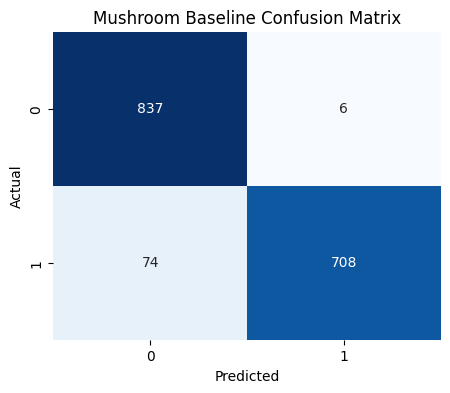

In [ ]:
plot_confusion_matrix(y_test_processed, y_pred_mushroom, "Mushroom Baseline Confusion Matrix")


# Experiment A: Feature Selection + Naive Bayes

In [ ]:

top_k_features = 7
selector = SelectKBest(score_func=f_classif, k=top_k_features)

X_train_selected = selector.fit_transform(X_train_processed, y_train_processed)
X_test_selected = selector.transform(X_test_processed)

nb_selected = CategoricalNaiveBayes()
nb_selected.fit(X_train_selected, y_train_processed)

y_pred_selected = nb_selected.predict(X_test_selected)

acc_selected = accuracy_score(y_test_processed, y_pred_selected)

print(f"=== Experiment A: Results with Top {top_k_features} Features ===")
print(f"Accuracy: {acc_selected:.4f}\n")
print("Detailed Performance Report:\n", classification_report(y_test_processed, y_pred_selected))

=== Experiment A: Results with Top 7 Features ===
Accuracy: 0.8800

Detailed Performance Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89       843
           1       0.95      0.80      0.86       782

    accuracy                           0.88      1625
   macro avg       0.89      0.88      0.88      1625
weighted avg       0.89      0.88      0.88      1625



/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


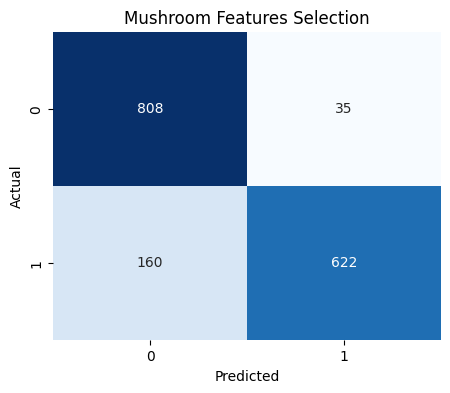

In [ ]:
plot_confusion_matrix(y_test_processed, y_pred_selected, "Mushroom Features Selection")

# Experiment B: PCA (Feature Reduction) + Naive Bayes

In [ ]:

k_components = 10

X_train_pca, eigenvalues, eigenvectors, mean_vector = pca(X_train_processed, k_components)

X_test_centered = X_test_processed - mean_vector
X_test_pca = np.dot(X_test_centered, eigenvectors)


X_train_pca_final = np.round(X_train_pca).astype(int)
X_test_pca_final = np.round(X_test_pca).astype(int)

nb_pca_model = CategoricalNaiveBayes()
nb_pca_model.fit(X_train_pca_final, y_train_processed)

y_pred_pca = nb_pca_model.predict(X_test_pca_final)

acc_pca = accuracy_score(y_test_processed, y_pred_pca)

print(f"=== Experiment B: Results with {k_components} PCA Components ===")
print(f"Accuracy: {acc_pca:.4f}\n")
print("Detailed Performance Report:\n", classification_report(y_test_processed, y_pred_pca))



=== Experiment B: Results with 10 PCA Components ===
Accuracy: 0.8775

Detailed Performance Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89       843
           1       0.90      0.83      0.87       782

    accuracy                           0.88      1625
   macro avg       0.88      0.88      0.88      1625
weighted avg       0.88      0.88      0.88      1625



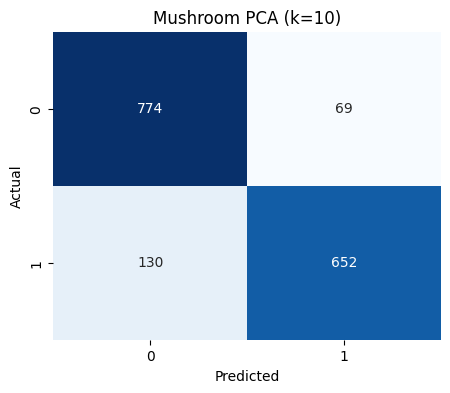

In [ ]:
plot_confusion_matrix(y_test_processed, y_pred_pca, f'Mushroom PCA (k={k_components})')

# Accuracy Comparison

In [ ]:
mushroom_results = {}
mushroom_results["Baseline (All Features)"] = acc_mushroom_baseline
mushroom_results['Feature Selection (k=10)'] = acc_selected
mushroom_results[f'PCA (k={k_components})'] = acc_pca

In [ ]:
comparison_df = pd.DataFrame({
    "Experiment": mushroom_results.keys(),
    "Accuracy": mushroom_results.values()
})
mushroom_df

,target,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


=== Mushroom Dataset: Final Performance Comparison ===


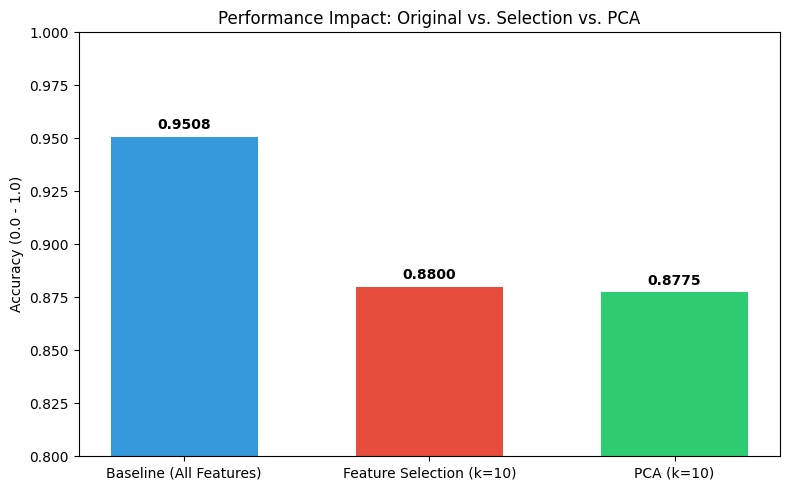

In [ ]:
print("=== Mushroom Dataset: Final Performance Comparison ===")
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df['Experiment'],
               comparison_df['Accuracy'],
               color=['#3498db', '#e74c3c', '#2ecc71'],
               width=0.6)

plt.ylabel('Accuracy (0.0 - 1.0)')
plt.title('Performance Impact: Original vs. Selection vs. PCA')
plt.ylim(0.80, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002,
             f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Part 4: Comparative Analysis and Report

## 4.1 Dataset Description

For this analysis, two distinct datasets were utilized to evaluate the performance and adaptability of the Naive Bayes algorithm in conjunction with dimensionality reduction techniques.

**Dataset 1: Mushroom (Categorical)**
* **Source:** UCI Machine Learning Repository.
* **Size:** 8,124 instances with 22 categorical features.
* **Class Distribution:** Edible (51.8%) and Poisonous (48.2%).
* **Justification:** This dataset is ideal for **Categorical Naive Bayes**. Since features like 'odor' and 'cap-shape' are discrete, the model can effectively estimate class-conditional probabilities for each category using Laplace smoothing to handle unseen values.

**Dataset 2: Breast Cancer Wisconsin (Numerical)**
* **Source:** Scikit-learn datasets (`load_breast_cancer`).
* **Size:** 569 instances with 30 numeric features.
* **Class Distribution:** 357 Benign and 212 Malignant.
* **Justification:** This dataset is perfectly suited for **Gaussian Naive Bayes**. The features represent continuous measurements (e.g., mean radius, area) which, when standardized, often approximate a normal distribution, aligning with the fundamental assumptions of the Gaussian model.

---

## 4.2 Implementation Details: PCA From Scratch

The Principal Component Analysis (PCA) was implemented from the ground up using NumPy to transform the high-dimensional feature space into a lower-dimensional subspace while preserving maximum variance.

**Mathematical Methodology:**
1. **Mean Centering:** To ensure the first principal component describes the direction of maximum variance, we center the data: $X_{centered} = X - \mu$.
2. **Covariance Matrix Calculation:** We compute the relationship between features using the formula: $\Sigma = \frac{1}{n} X_{centered}^T X_{centered}$.
3. **Eigen-Decomposition:** We solve for eigenvalues ($\lambda$) and eigenvectors ($v$) such that $\Sigma v = \lambda v$. In the implementation, `np.linalg.eigh` is used for numerical stability.
4. **Component Selection:** Eigenvalues are sorted in descending order. We select the top $k$ eigenvectors to form a projection matrix $W$.
5. **Dimensionality Reduction:** The original data is projected onto the new axes: $X_{reduced} = X_{centered} \cdot W$.

---

## 4.3 Results and Comparison

### Accuracy Summary Table

| Experiment | Mushroom (Categorical) | Breast Cancer (Numerical) |
| :--- | :---: | :---: |
| **Baseline (All Features)** | **95.08%** | **96.49%** |
| **Feature Selection (SelectKBest)** | **88.00%** | **92.10%** |
| **PCA (From Scratch)** | **87.75%** | **94.73%** |



### Discussion and Answers

1. How did Naive Bayes perform on categorical versus numerical data?

Naive Bayes performed exceptionally well on both types of data, with baseline accuracies exceeding 95% for both datasets. For the categorical Mushroom dataset, `CategoricalNB` effectively calculated exact probabilities based on category counts. For the numerical Breast Cancer dataset, `GaussianNB` performed smoothly because the continuous features (especially after standardization) fit the algorithm's assumption of a normal (bell-curve) distribution very well.

2. Which approach achieved better results for each dataset? Why?

For both datasets, the **Baseline approach (using all original features)** achieved the highest accuracy (95.08% for Mushrooms and 96.49% for Breast Cancer).

* **Why:** Naive Bayes models rely on aggregating evidence from multiple independent features. When we use Feature Selection, we permanently discard potentially useful evidence. When we use PCA, we compress the data, which can sometimes blur the distinct, independent signals that Naive Bayes uses to separate classes.

3. How did both methods compare to the baseline model?

Both Feature Selection and PCA resulted in a drop in accuracy compared to the baseline for both datasets.

* On the **numerical dataset**, PCA (94.73%) performed better than Feature Selection (92.10%) and stayed very close to the baseline. This shows that capturing the overall variance of the 30 numerical features was better than throwing features away.
* On the **categorical dataset**, both methods dropped significantly (around 87-88%). This indicates that Categorical Naive Bayes relies heavily on the specific, uncompressed physical traits of the mushrooms to make accurate predictions.

4. What are the trade-offs between feature selection and feature reduction?


* **Feature Selection (e.g., SelectKBest):** The main advantage is **interpretability**. We keep actual, real-world features (like "radius" or "odor"), meaning we can explain exactly *why* the model made a decision. The trade-off is information loss; any feature not selected is completely ignored.
* **Feature Reduction (e.g., PCA):** The main advantage is **information retention**. PCA compresses the dataset by creating new components that contain a blended summary of *all* original features. The massive trade-off is a complete loss of interpretability—a "Principal Component" is a mathematical abstraction, so we can no longer trace a prediction back to a specific physical trait.

5. Is PCA appropriate for categorical data?
Discuss any issues observed.
Technically, no. PCA is designed for continuous, numerical data where the variance and mathematical "distance" between data points have real meaning.

* **Issues observed:** Categorical data (like encoding "red" as 0 and "blue" as 1) has no meaningful mathematical distance (1 is not "greater" than 0 in terms of color). When we applied PCA to the Mushroom dataset, it generated continuous decimal values. Because our `CategoricalNaiveBayes` model expects discrete integer categories, we had to use `np.round()` to force the PCA outputs back into whole numbers. This forced discretization introduced noise and destroyed the exact probability mappings, directly causing the accuracy to drop to 87.75%.

# Accuracy Comparison Bar Charts

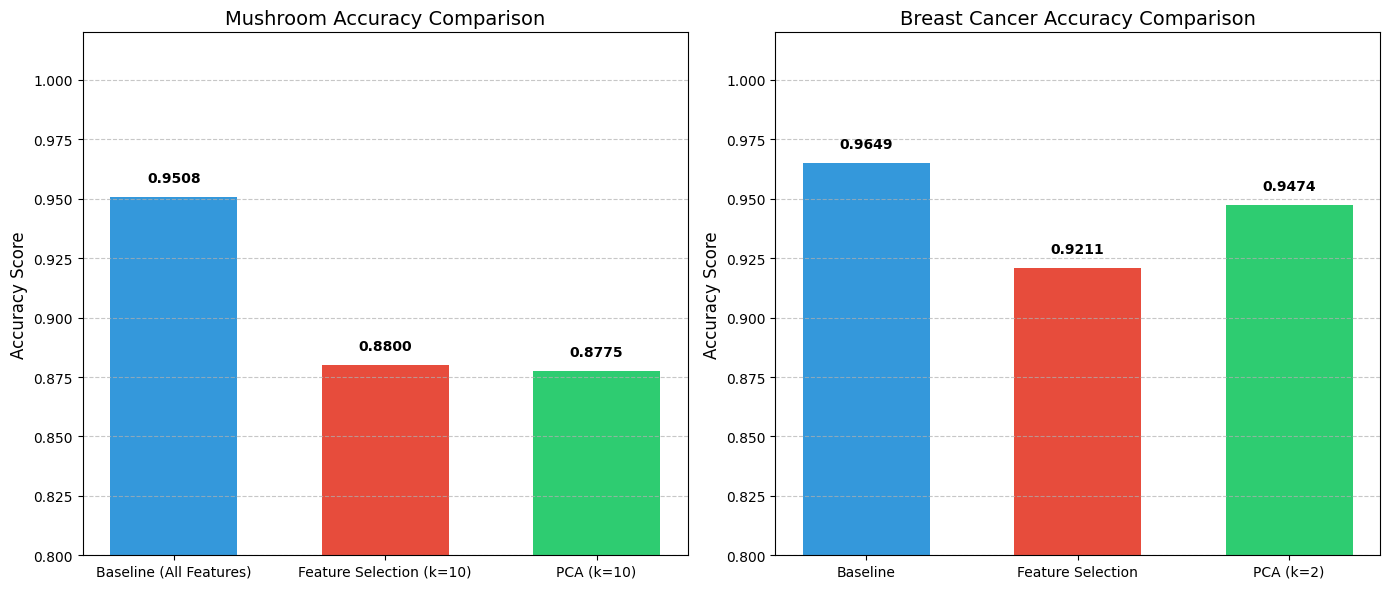

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71'] # Blue, Red, Green

axes[0].bar(mushroom_results.keys(), mushroom_results.values(), color=colors, width=0.6)
axes[0].set_title('Mushroom Accuracy Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy Score', fontsize=12)
axes[0].set_ylim(0.80, 1.02)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(mushroom_results.values()):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

axes[1].bar(accuracy_results.keys(), accuracy_results.values(), color=colors, width=0.6)
axes[1].set_title('Breast Cancer Accuracy Comparison', fontsize=14)
axes[1].set_ylabel('Accuracy Score', fontsize=12)
axes[1].set_ylim(0.80, 1.02)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(accuracy_results.values()):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# PCA Scree Plots

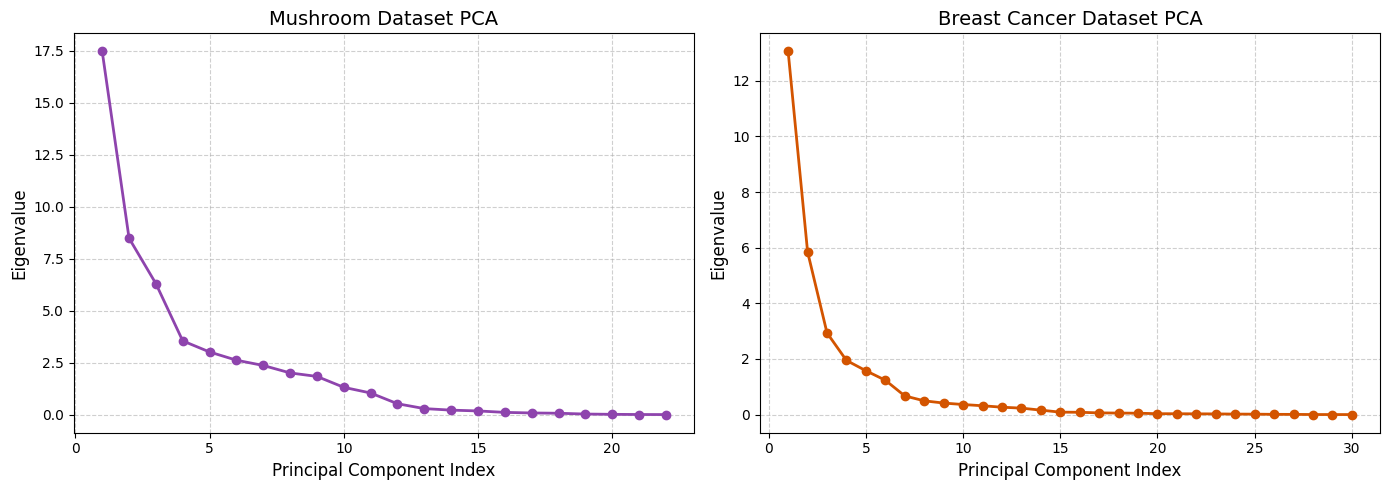

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', color='#8e44ad', linewidth=2)
axes[0].set_title('Mushroom Dataset PCA', fontsize=14)
axes[0].set_xlabel('Principal Component Index', fontsize=12)
axes[0].set_ylabel('Eigenvalue', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)


axes[1].plot(range(1, len(eigen_vals) + 1), eigen_vals, marker='o', linestyle='-', color='#d35400', linewidth=2)
axes[1].set_title('Breast Cancer Dataset PCA', fontsize=14)
axes[1].set_xlabel('Principal Component Index', fontsize=12)
axes[1].set_ylabel('Eigenvalue', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()